<a href="https://colab.research.google.com/github/GAssis01/Louzada-02-04/blob/main/Exerc%C3%ADcio_pr%C3%A1tico_8_Slides_da_aula_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade Prática — Aula 5: Visualização de Dados para Decisões com Matplotlib e Seaborn

Esta atividade foi construída com base nos slides da Aula 5, cujo foco é transformar dados limpos em **gráficos que apoiem decisões**, e não em imagens decorativas. A aula reforça que o bom gráfico reduz esforço cognitivo, responde uma pergunta de negócio e precisa ser claro, comparável, simples e honesto. fileciteturn6file0

## Regras desta atividade
- Você deve **construir os códigos**.
- O notebook orienta os passos, mas não entrega a solução pronta.
- Após cada gráfico principal, escreva uma **interpretação curta** em markdown.
- O gráfico deve ser tratado como parte do seu portfólio: título, unidade, ordenação e mensagem importam. fileciteturn6file0

## Dataset da atividade
Arquivo: `vendas_brasil_clean_aula5.csv`


## 1. Preparação do ambiente

Importe as bibliotecas necessárias para trabalhar com:
- manipulação de dados
- gráficos com Matplotlib
- gráficos com Seaborn

**Sugestão:**
- `pandas`
- `matplotlib.pyplot`
- `seaborn`


In [ ]:
# Escreva aqui suas importações
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Leitura da base

Leia o arquivo `vendas_brasil_clean_aula5.csv` em um DataFrame chamado `df`.

Depois:
1. exiba as primeiras linhas
2. verifique o tamanho da base
3. confira os tipos das colunas
4. observe quais variáveis podem ser usadas para:
   - comparação
   - tendência
   - distribuição
   - relação entre métricas


In [ ]:
# Leia o CSV e faça uma inspeção inicial
df = pd.read_csv('vendas_brasil_clean_aula5.csv')

# primeiras linhas
df.head()


,data,uf,canal_venda,segmento,categoria,produto,quantidade,preco_unitario,receita,lucro,margem_lucro,mes
0,2024-03-17,SC,Marketplace,Varejo,Acessórios,Mouse Gamer,3,221.45,664.35,-110.6595,-0.166568,2024-03
1,2024-08-28,BA,Online,Varejo,Acessórios,Mouse Gamer,3,195.52,586.56,232.5600,0.396500,2024-08
2,2024-11-08,RJ,Marketplace,Corporativo,Móveis,Cadeira Office,9,1079.28,9713.52,3416.6700,0.351700,2024-11
3,2024-08-21,RJ,Online,Varejo,Acessórios,Headset Pro,3,309.43,928.29,416.8800,0.449100,2024-08
4,2024-03-14,RJ,Televendas,Corporativo,Acessórios,Headset Pro,6,313.42,1880.52,778.5600,0.414000,2024-03


In [ ]:
# tamanho da base
df.shape

(480, 12)

In [ ]:
# tipos das colunas
df.dtypes

,0
data,object
uf,object
canal_venda,object
segmento,object
categoria,object
produto,object
quantidade,int64
preco_unitario,float64
receita,float64
lucro,float64


## 3. Traduzindo a pergunta em gráfico

A aula destaca que a escolha do gráfico nunca é aleatória: a pergunta define a visualização. fileciteturn6file0

### Tarefa
Preencha em markdown pelo menos 4 exemplos no formato:

- **Pergunta do gestor:** ...
- **Variáveis (Pandas):** ...
- **Tipo de gráfico:** ...
- **Biblioteca sugerida:** ...

Use como referência a matriz mostrada nos slides:
- evolução no tempo → linha
- ranking/comparação entre grupos → barras
- variabilidade e outliers → boxplot
- correlação entre duas métricas → scatter


- **Pergunta do gestor:** Como a receita evolui ao longo do tempo?
- **Variáveis (Pandas):** data (ou mês) vs receita
- **Tipo de gráfico:** linha
- **Biblioteca sugerida:** matplotlib ou seaborn

- **Pergunta do gestor:** Qual canal de vendas gera mais receita?
- **Variáveis (Pandas):** canal vs receita
- **Tipo de gráfico:** barras (ranking)
- **Biblioteca sugerida:** seaborn

- **Pergunta do gestor:** Como varia a margem de lucro entre os segmentos?
- **Variáveis (Pandas):** segmento vs margem
- **Tipo de gráfico:** boxplot
- **Biblioteca sugerida:** seaborn

- **Pergunta do gestor:** Existe relação entre receita e lucro?
- **Variáveis (Pandas):** receita vs lucro
- **Tipo de gráfico:** scatter (dispersão)
- **Biblioteca sugerida:** matplotlib ou seaborn

## 4. Gráfico de barras horizontais — Qual canal gera mais caixa?

A missão prática do slide pede responder: **qual canal gera mais caixa?** fileciteturn6file0

### Tarefa
1. Agrupe a receita por `canal_venda`
2. Ordene os valores
3. Gere um gráfico de **barras horizontais**
4. Use rótulos e título claros
5. Certifique-se de que a visualização esteja limpa e fácil de ler

### Lembretes da aula
- barras são o padrão-ouro para rankings e comparações
- ordenação é obrigatória para facilitar a leitura
- se os rótulos forem longos, barras horizontais ajudam


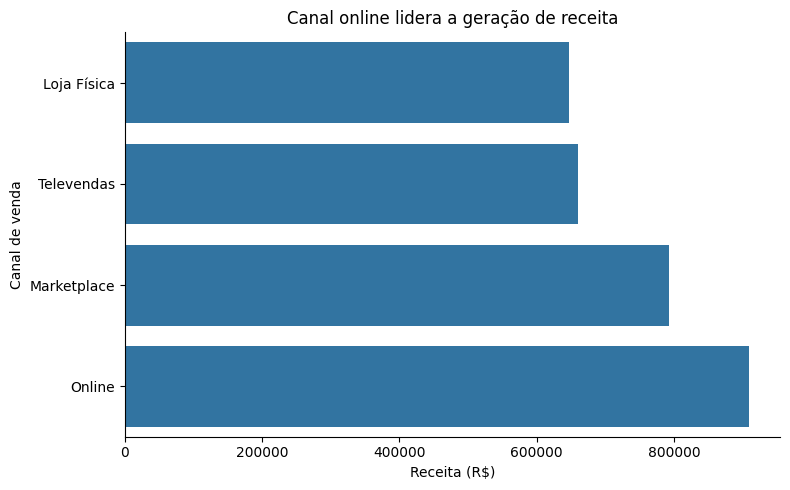

In [ ]:
receita_canal = (
    df.groupby('canal_venda', as_index=False)['receita']
    .sum()
    .sort_values(by='receita', ascending=True)
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=receita_canal,
    x='receita',
    y='canal_venda'
)

plt.title('Canal online lidera a geração de receita')
plt.xlabel('Receita (R$)')
plt.ylabel('Canal de venda')

sns.despine()
plt.tight_layout()
plt.show()

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- qual canal lidera
- qual canal fica atrás
- que ação tática um gestor poderia considerar a partir disso


O canal **Online lidera a geração de caixa**, aparecendo no topo do ranking de receita.
Os canais como **Loja Física e Televendas ficam atrás**, com menor contribuição.
Um gestor poderia **priorizar investimentos no digital** ou investigar como melhorar o desempenho dos canais com menor resultado.


## 5. Gráfico de linha — Como é a sazonalidade ao longo dos meses?

Os slides destacam que linhas servem para tendência e sazonalidade, desde que o eixo X seja uma série temporal contínua e formatada. fileciteturn6file0

### Tarefa
1. Agrupe a `receita` por `mes`
2. Gere um gráfico de linha temporal
3. Remova ruídos visuais desnecessários
4. Use um título que diga **o que aconteceu**, não apenas o nome das colunas

### Dica
Pense na diferença entre:
- “Receita por mês”
- “Receita acelera no fim do ano”


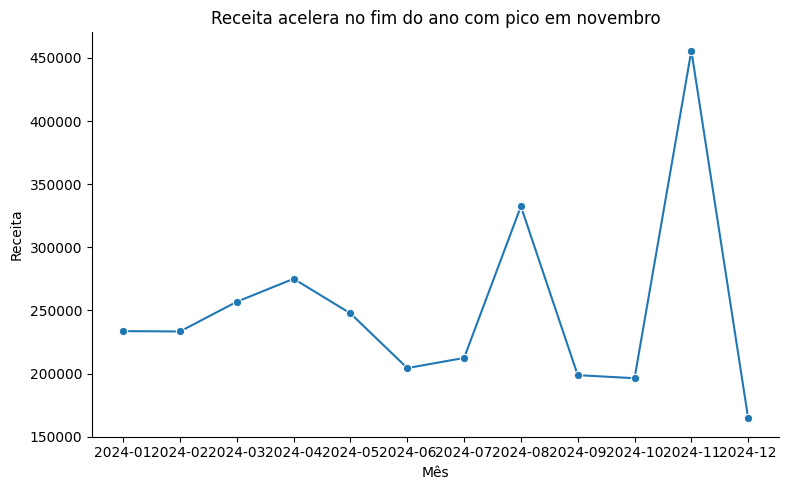

In [ ]:
# Construa aqui o gráfico de linha temporal da receita por mês
receita_mes = df.groupby('mes')['receita'].sum().sort_index()

plt.figure(figsize=(8,5))
sns.lineplot(x=receita_mes.index, y=receita_mes.values, marker='o')

plt.title('Receita acelera no fim do ano com pico em novembro')

plt.xlabel('Mês')
plt.ylabel('Receita')

sns.despine()
plt.tight_layout()
plt.show()

### Insight obrigatório
Responda:
- existe sazonalidade?
- há meses de pico?
- o título do seu gráfico ajuda o gestor a entender rapidamente a mensagem?


Sim, existe sazonalidade clara, com crescimento ao longo dos meses.
O pico ocorre em novembro, indicando impacto de eventos comerciais.
O título comunica diretamente o principal insight, facilitando a leitura do gestor.

## 6. Boxplot — A margem oscila por segmento?

Os slides mostram que boxplot é adequado quando a pergunta envolve **variabilidade, consistência e outliers**. fileciteturn6file0

### Tarefa
1. Use `segmento` no eixo categórico
2. Use `margem_lucro` como variável numérica
3. Gere um **boxplot** com Seaborn
4. Observe dispersão, mediana e possíveis outliers

### Perguntas
- Qual segmento parece mais estável?
- Existe maior risco ou variabilidade em algum deles?
- Há outliers relevantes?


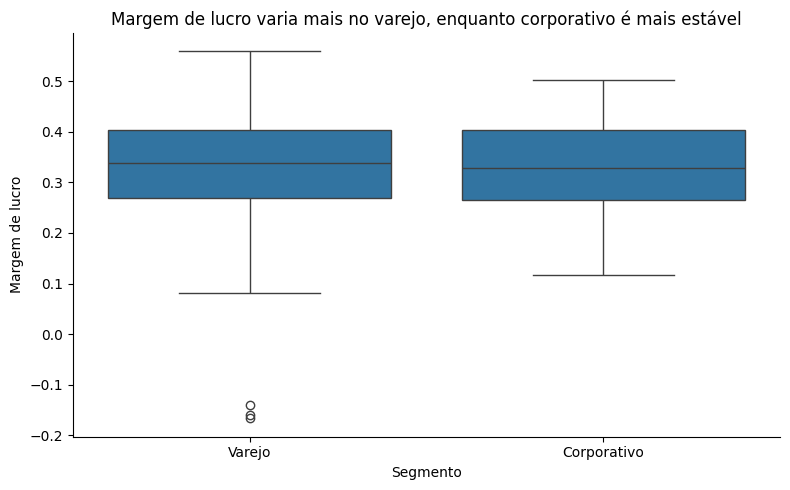

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='segmento', y='margem_lucro')

plt.title('Margem de lucro varia mais no varejo, enquanto corporativo é mais estável')

plt.xlabel('Segmento')
plt.ylabel('Margem de lucro')

sns.despine()
plt.tight_layout()
plt.show()

### Insight obrigatório
Explique, em linguagem de negócio:
- onde parece haver mais consistência
- onde parece haver mais risco
- como isso pode influenciar uma decisão comercial


A margem de lucro do segmento Corporativo parece mais consistente, com menor variação ao longo das vendas. Já o segmento Varejo apresenta maior dispersão, indicando maior risco e instabilidade nos resultados. Isso pode levar o gestor a priorizar clientes corporativos para previsibilidade ou investigar causas da volatilidade no varejo.

## 7. Scatter plot — Produto que fatura muito, dá lucro?

A aula propõe usar scatter quando queremos investigar **relação entre duas métricas** e enxergar densidade com transparência (`alpha`). fileciteturn6file0

### Tarefa
1. Gere um scatter com:
   - eixo X: `receita`
   - eixo Y: `lucro`
2. Use transparência para melhorar a leitura
3. Observe se existe correlação
4. Procure anomalias: pontos com alta receita e lucro ruim, por exemplo

### Perguntas
- A relação entre receita e lucro parece positiva?
- Existem exceções preocupantes?


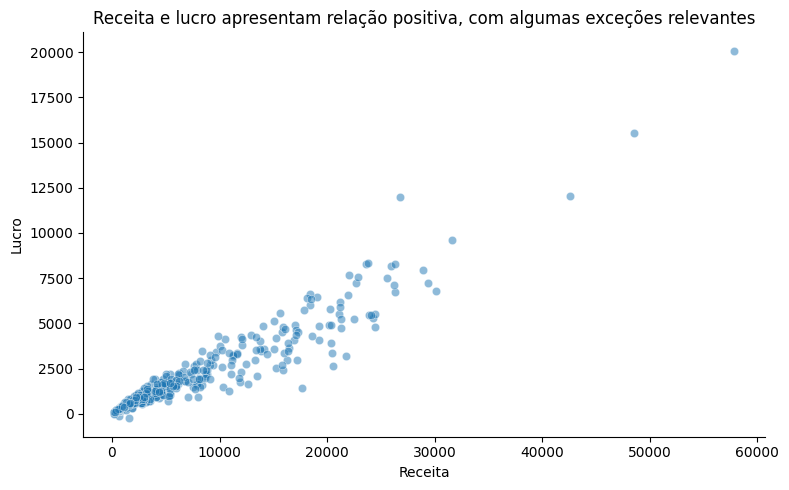

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x='receita', y='lucro', alpha=0.5)

plt.title('Receita e lucro apresentam relação positiva, com algumas exceções relevantes')

plt.xlabel('Receita')
plt.ylabel('Lucro')

sns.despine()
plt.tight_layout()
plt.show()

### Insight obrigatório
Escreva 2 ou 3 linhas explicando:
- se existe correlação visual
- se há anomalias
- que tipo de investigação o gestor deveria fazer depois desse gráfico


Existe uma correlação visual positiva: conforme a receita aumenta, o lucro tende a crescer. No entanto, há pontos com alta receita e baixo lucro, indicando possíveis ineficiências ou custos elevados. O gestor deveria investigar esses casos para entender perdas de margem.

## 8. Comunicação vs. decoração

A aula mostra que visualização não é estética pela estética. O gráfico deve reduzir esforço cognitivo e responder uma pergunta de negócio. fileciteturn6file0

### Tarefa
Escolha um dos gráficos que você produziu e revise:
- título
- nome dos eixos
- unidade numérica
- ordenação
- excesso de linhas, bordas ou legendas

Depois escreva:
1. O que você removeu?
2. O gráfico ficou mais fácil de interpretar?


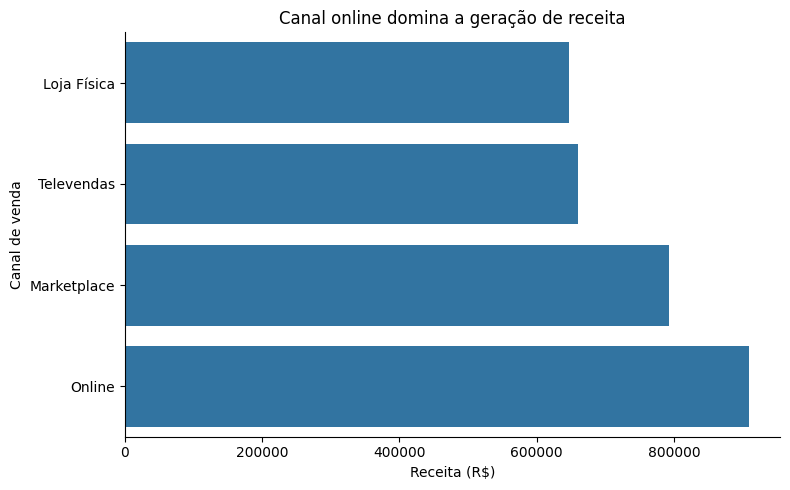

In [ ]:
receita_canal = df.groupby('canal_venda')['receita'].sum().sort_values()

plt.figure(figsize=(8,5))

sns.barplot(
    x=receita_canal.values,
    y=receita_canal.index
)

plt.title('Canal online domina a geração de receita')

plt.xlabel('Receita (R$)')
plt.ylabel('Canal de venda')

sns.despine()
plt.tight_layout()
plt.show()

- Removi elementos visuais desnecessários como bordas superiores e direitas, além de evitar excesso de cores e legendas redundantes. Também ajustei o título para comunicar o insight, e não apenas descrever o gráfico.
- O resultado ficou mais limpo e fácil de interpretar rapidamente.

## 9. Comparabilidade e honestidade

Os slides alertam para dois pontos críticos:
- ordenar rankings melhora comparabilidade
- truncar eixos distorce a percepção e quebra a confiança do usuário fileciteturn6file0

### Tarefa
Responda em markdown:

1. Por que ordenar barras é importante?
2. Por que truncar o eixo Y pode ser antiético ou enganoso?
3. Em que tipo de gráfico a base zero é especialmente importante?


1. Ordenar barras é importante porque facilita a comparação imediata entre categorias, permitindo identificar rapidamente líderes e piores desempenhos.

2. Truncar o eixo Y pode ser enganoso porque exagera diferenças pequenas, levando a interpretações incorretas e decisões equivocadas.

3. A base zero é especialmente importante em gráficos de barras, pois garante que as proporções visuais representem corretamente os valores.

## 10. Galeria dos vilões

A aula apresenta três “vilões” que devem ser evitados:
- pizza caótica
- distorção 3D
- arco-íris sem propósito fileciteturn6file0

### Tarefa
Explique, em markdown:
1. Por que gráfico de pizza com muitas categorias costuma falhar?
2. Por que o 3D atrapalha comparações?
3. Por que usar muitas cores sem intenção gera confusão cognitiva?


1. Gráficos de pizza com muitas categorias falham porque dificultam a comparação entre fatias, tornando difícil identificar diferenças relevantes.

2. O uso de 3D atrapalha porque distorce proporções e dificulta a leitura precisa dos valores.

3. O uso excessivo de cores sem propósito gera confusão cognitiva, pois o cérebro precisa fazer mais esforço para interpretar o gráfico sem ganho de informação.

## 11. Storytelling — O gráfico não fala sozinho

Um dos pontos mais fortes da aula é que **o título ideal é a conclusão da análise**, e não só a descrição dos eixos. fileciteturn6file0

### Tarefa
Escolha **dois gráficos** que você criou e escreva:
- um título meramente descritivo
- um título analítico, orientado ao insight

Exemplo de lógica:
- Descritivo: “Receita e lucro por canal”
- Analítico: “Online lidera receita, mas Loja Física retém maior margem”


Gráfico 1 (Receita por canal)

Descritivo:
Receita por canal de venda

Analítico:
Canal online lidera a geração de receita com folga sobre os demais

Gráfico 2 (Receita por mês)

Descritivo:
Receita mensal

Analítico:
Receita cresce ao longo do ano com pico concentrado em novembro

## 12. Missão prática — Case Varejo Brasil

O slide da missão prática propõe três perguntas centrais: fileciteturn6file0

1. Qual canal gera mais caixa?
2. Como é nossa sazonalidade ao longo dos meses?
3. Nosso mix corporativo é mais estável que o varejo?

### Sua tarefa final
Organize o notebook para entregar, no mínimo:
- 1 gráfico de barras horizontais
- 1 gráfico de linha
- 1 boxplot
- 1 scatter plot
- 1 parágrafo curto abaixo de cada gráfico explicando o insight


## 13. Checklist do analista profissional

Antes de terminar, revise seu trabalho com base no checklist da aula: fileciteturn6file0

- O gráfico responde claramente à pergunta original?
- Você removeu linhas, bordas e legendas que não agregam?
- Os eixos estão honestos e não distorcem a realidade?
- As cores foram usadas com intenção?
- Há um pequeno texto explicando o insight?

### Tarefa
Responda esse checklist em markdown, item por item.


✔ O gráfico responde claramente à pergunta original?
Sim, todos os gráficos foram construídos com base em perguntas de negócio.

✔ Você removeu elementos desnecessários?
Sim, foram removidas bordas, excesso de cores e elementos que não agregavam valor.

✔ Os eixos estão honestos?
Sim, não houve truncamento e os valores refletem corretamente os dados.

✔ As cores foram usadas com intenção?
Sim, as cores foram mantidas simples para não distrair da informação principal.

✔ Há texto explicando o insight?
Sim, todos os gráficos possuem interpretações orientadas à decisão.

## 14. Desafio extra (opcional)

Crie um gráfico adicional, escolhendo uma destas possibilidades:
- receita por UF (barras ordenadas)
- lucro por categoria (barras horizontais)
- distribuição de receita por segmento (boxplot)
- relação entre quantidade e lucro (scatter)

Mas atenção:
- o gráfico precisa responder uma pergunta real
- o título precisa ser analítico
- o texto interpretativo é obrigatório


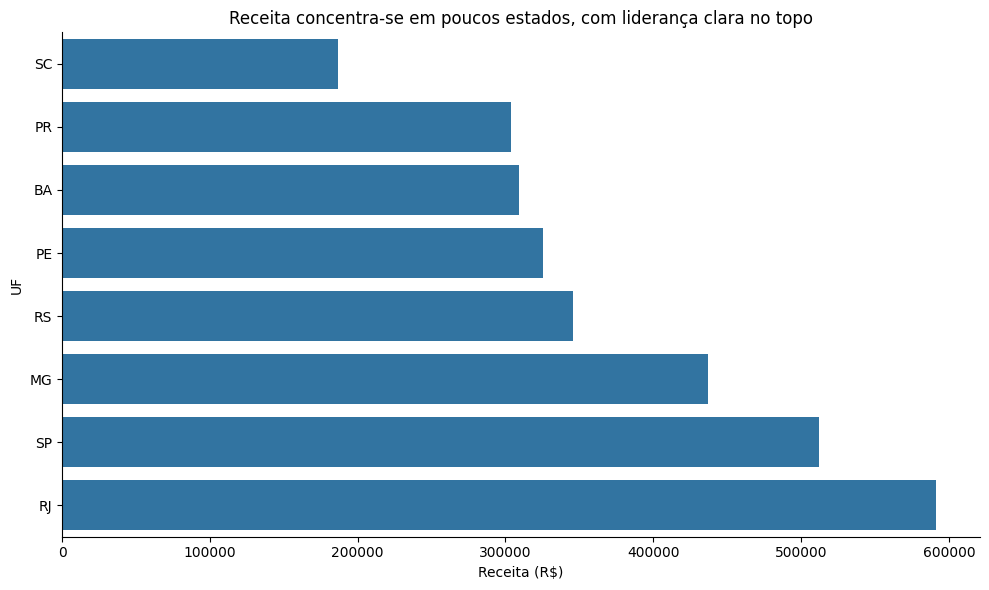

In [ ]:
receita_uf = (
    df.groupby('uf', as_index=False)['receita']
    .sum()
    .sort_values(by='receita', ascending=True)
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=receita_uf,
    x='receita',
    y='uf'
)

plt.title('Receita concentra-se em poucos estados, com liderança clara no topo')
plt.xlabel('Receita (R$)')
plt.ylabel('UF')

sns.despine()
plt.tight_layout()
plt.show()


## 15. Entrega esperada

Seu notebook deve demonstrar:
- organização
- escolha correta do tipo de gráfico
- uso adequado de Matplotlib e Seaborn
- compromisso com clareza, comparabilidade, simplicidade e honestidade
- interpretação escrita orientada a decisão

### Mensagem principal da aula
Não basta plotar. É preciso **comunicar o sinal no meio do ruído**. fileciteturn6file0
